# Choose Your Benchmark \U0001F3AF
### Alpha is a subtraction. Change what you subtract and you change the answer.

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

Every alpha you have ever read is the answer to a question of the form "compared to *what*?"
The comparison is a choice, it is usually made by the person being measured, and the range of
defensible choices turns out to be wider than the numbers being argued over.

> \U0001F4D3 **This is the plain-language layer.** The full grid, the bootstrap over benchmarks
> and the planted-zero-alpha control are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does the benchmark move the alpha? | By more than the reported error bar. |
| Can it flip the sign? | For most funds here, yes. |
| Can the data pick the right one? | Usually not. |
| Can a wrong one invent alpha? | Yes, and significant alpha. |

## 1 · The same funds, nine yardsticks

In [2]:
from benchmark import data, strategy as st

px = data.load_prices()
R = px.pct_change()
fcols = [c for c in data.FUNDS if c in R.columns and R[c].dropna().shape[0] > 1500]
bcols = [c for c in data.BENCHMARKS if c in R.columns
         and R[c].dropna().shape[0] > 1500]
funds, benches = R[fcols], R[bcols]
rf = R[data.BILLS] if data.BILLS in R.columns else None
print(f"as-of {data.AS_OF} | {len(fcols)} funds, {len(bcols)} candidate benchmarks")
print(f"benchmarks: {', '.join(bcols)}")

as-of 2026-06-30 | 17 funds, 9 candidate benchmarks
benchmarks: SPY, VTI, IWD, IWF, IWM, IWN, IWO, IJH, EFA


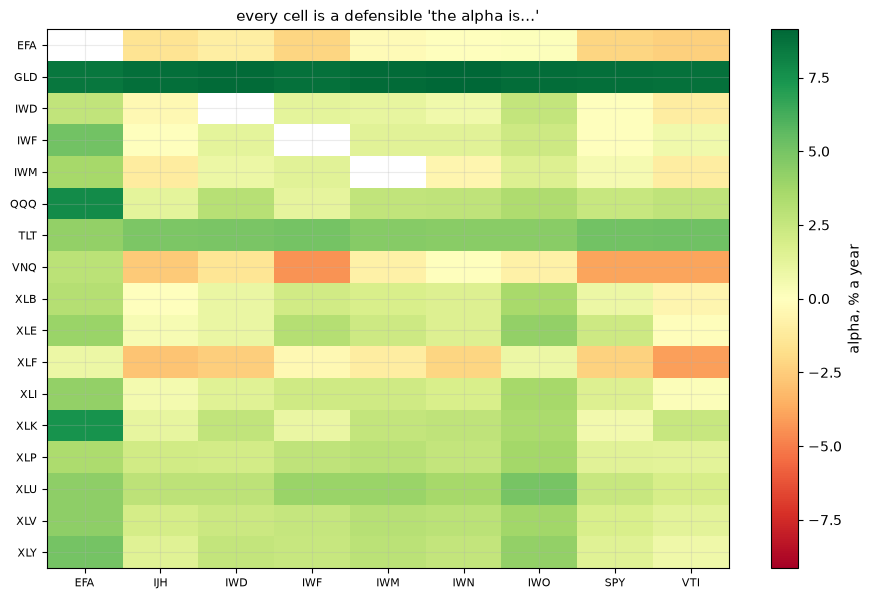

benchmark    EFA     IJH     IWD     IWF     IWM     IWN     IWO     SPY     VTI
fund                                                                            
EFA          NaN -1.5600 -0.9600 -2.1700 -0.2600 -0.0200  0.1300 -2.1500 -2.3800
GLD       8.5400  8.8200  8.9700  8.7100  8.9900  9.1400  8.8700  8.8500  8.7700
IWD       2.6900 -0.4000     NaN  1.2800  1.0900  0.6500  2.6000  0.0700 -1.0500
IWF       5.1200 -0.0100  1.2200     NaN  1.4200  1.3900  2.2600 -0.0300  0.6900
IWM       3.6300 -1.0700  0.8900  1.3700     NaN -0.5300  1.6300  0.4300 -1.0400
QQQ       7.7500  1.2800  3.0200  1.1600  2.6900  2.7500  3.3400  2.4500  2.7700
TLT       4.1600  4.8500  4.8700  5.0600  4.5300  4.4500  4.4500  5.1300  5.1500
VNQ       2.8700 -2.6000 -1.4300 -4.3700 -0.8300 -0.0300 -0.7900 -3.8600 -3.9100
XLB       3.1000  0.0600  0.9900  2.0800  1.7900  1.5800  3.5500  0.8600 -0.5200
XLE       3.9600  0.3700  0.9900  3.1100  2.2600  1.5900  4.1500  2.2500 -0.1200
XLF       0.8900 -2.8500 -2.

In [3]:
grid = st.alpha_grid(funds, benches, rf)
piv = grid.pivot(index="fund", columns="benchmark", values="alpha") * 100
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(piv.to_numpy(), cmap="RdYlGn", aspect="auto",
               vmin=-np.nanmax(np.abs(piv.to_numpy())),
               vmax=np.nanmax(np.abs(piv.to_numpy())))
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, fontsize=8)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index, fontsize=8)
plt.colorbar(im, ax=ax, label="alpha, % a year")
ax.set_title("every cell is a defensible 'the alpha is...'", fontsize=11)
plt.show()
print(piv.round(2).to_string())

Read across any row. Those are all the same fund, over the same period, measured honestly. The
only thing that changed is the comparison.

## 2 · Is that bigger than the error bar?

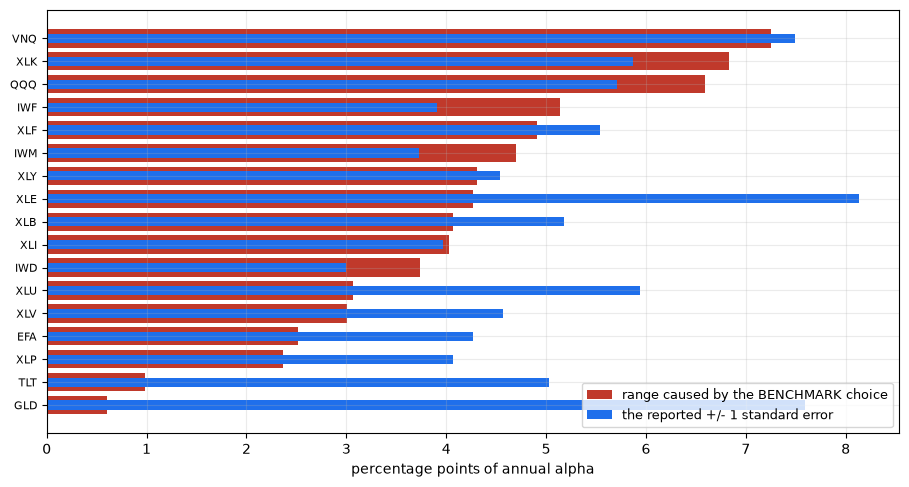

median spread from the choice: 4.07%
median standard error:         2.52%
ratio: 1.8x


In [4]:
rng_tbl = st.alpha_range(grid)
fig, ax = plt.subplots(figsize=(11, 5.5))
d = rng_tbl.sort_values("alpha_spread")
y = np.arange(len(d))
ax.barh(y, d["alpha_spread"] * 100, color="#c0392b",
        label="range caused by the BENCHMARK choice")
ax.barh(y, d["median_se"] * 2 * 100, height=0.4, color="#1f6feb",
        label="the reported +/- 1 standard error")
ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=8)
ax.set_xlabel("percentage points of annual alpha"); ax.legend(fontsize=9)
plt.show()
print(f"median spread from the choice: {rng_tbl['alpha_spread'].median():.2%}")
print(f"median standard error:         {rng_tbl['median_se'].median():.2%}")
print(f"ratio: {rng_tbl['spread_over_se'].median():.1f}x")

The red bars are the uncertainty nobody reports. The blue bars are the uncertainty that gets a
confidence interval, a p-value and a footnote.

## 3 · Same fund, opposite conclusions

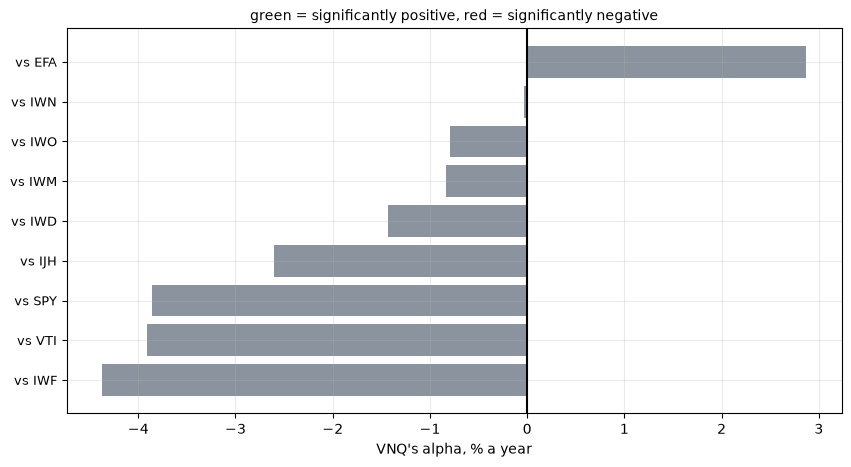

benchmark   alpha  alpha_t     r2
      IWF -0.0440  -1.0400 0.4590
      VTI -0.0390  -1.0620 0.5800
      SPY -0.0390  -1.0320 0.5660
      IJH -0.0260  -0.7350 0.6150
      IWD -0.0140  -0.4070 0.6380
      IWM -0.0080  -0.2220 0.5930
      IWO -0.0080  -0.1980 0.5080
      IWN -0.0000  -0.0100 0.6320
      EFA  0.0290   0.7040 0.4850


In [5]:
flippers = rng_tbl[rng_tbl["significant_both_ways"]]
if len(flippers) == 0:
    flippers = rng_tbl[rng_tbl["sign_flips"]]
name = flippers["alpha_spread"].idxmax() if len(flippers) else \
    rng_tbl["alpha_spread"].idxmax()
g = grid[grid["fund"] == name].sort_values("alpha")
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ea44f" if t > 2 else "#c0392b" if t < -2 else "#8b949e"
          for t in g["alpha_t"]]
ax.barh(range(len(g)), g["alpha"] * 100, color=colors)
ax.axvline(0, color="k", lw=1.5)
ax.set_yticks(range(len(g)))
ax.set_yticklabels([f"vs {b}" for b in g["benchmark"]], fontsize=9)
ax.set_xlabel(f"{name}'s alpha, % a year")
ax.set_title("green = significantly positive, red = significantly negative",
             fontsize=10)
plt.show()
print(g[["benchmark", "alpha", "alpha_t", "r2"]].round(3).to_string(index=False))

> \U0001F52C **For the quants.** Both the green and the red bars clear |t| > 2 with Newey-West
> standard errors. A researcher could publish "significant outperformance" or "significant
> underperformance" for this fund without doing anything improper.

## 4 · Where a wrong yardstick comes from

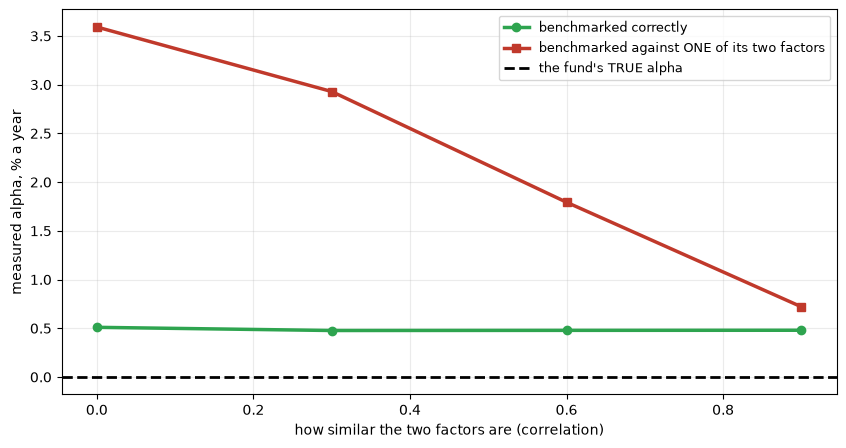

             true_alpha  alpha_correct  alpha_only_f1  alpha_only_f2  error_only_f1  error_only_f2
factor_corr                                                                                       
0.0000           0.0000         0.0051         0.0359         0.0641         0.0359         0.0641
0.3000           0.0000         0.0048         0.0293         0.0666         0.0293         0.0666
0.6000           0.0000         0.0048         0.0179         0.0428         0.0179         0.0428
0.9000           0.0000         0.0048         0.0072         0.0164         0.0072         0.0164


In [6]:
dmg = st.mis_specification_damage(true_alpha=0.0,
                                  factor_corr_grid=(0.0, 0.3, 0.6, 0.9),
                                  n_days=4000, n_reps=8)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dmg.index, dmg["alpha_correct"] * 100, "o-", lw=2.5, color="#2ea44f",
        label="benchmarked correctly")
ax.plot(dmg.index, dmg["alpha_only_f1"] * 100, "s-", lw=2.5, color="#c0392b",
        label="benchmarked against ONE of its two factors")
ax.axhline(0, color="k", lw=2, ls="--", label="the fund's TRUE alpha")
ax.set_xlabel("how similar the two factors are (correlation)")
ax.set_ylabel("measured alpha, % a year"); ax.legend(fontsize=9)
plt.show()
print(dmg.round(4).to_string())

Every point on this chart is a fund with **no skill whatsoever** — the alpha is zero by
construction. The green line finds that. The red line invents up to several percent a year, and
it does most damage when the benchmarks are *least* alike, which is the reverse of what people
assume.

## 5 · Is the fiction convincing?

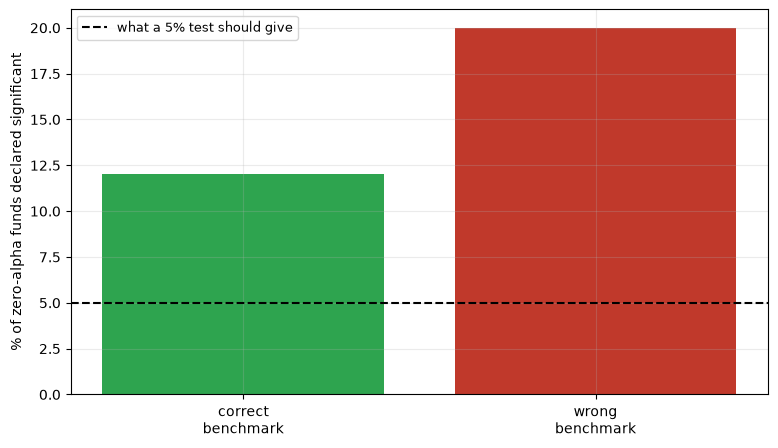

mean false alpha from the wrong benchmark: +1.51% +/- 4.29%


In [7]:
s = st.false_alpha_significance(true_alpha=0.0, n_days=3000, n_reps=50)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(["correct\nbenchmark", "wrong\nbenchmark"],
       [s["share_significant_right_benchmark"] * 100,
        s["share_significant_wrong_benchmark"] * 100],
       color=["#2ea44f", "#c0392b"])
ax.axhline(5, color="k", ls="--", lw=1.5, label="what a 5% test should give")
ax.set_ylabel("% of zero-alpha funds declared significant"); ax.legend(fontsize=9)
plt.show()
print(f"mean false alpha from the wrong benchmark: {s['mean_false_alpha']:+.2%} "
      f"+/- {s['sd_false_alpha']:.2%}")

## 6 · The verdict

**Signal: Weak.** Enormously, and by more than the noise everyone does report. Running 17 funds against 9 defensible benchmarks, the median fund's alpha ranged over **4.07% a year** depending only on what it was measured against — **1.8× the median standard error** of any single estimate. The specification is a larger source of uncertainty than the sampling error that gets the confidence interval, and it is the one with no error bar at all. **47% of funds change the sign of their alpha** across benchmarks, and 0% are *significantly positive against one benchmark and significantly negative against another* — both at |t| > 2, both defensible, both publishable. The worst case here was VNQ, spanning 7.25%. Nor is this only a matter of picking obviously wrong comparators: climbing the specification ladder from a single market factor to five, alpha moved from +0.60% to +1.62% for the headline fund, with every rung a specification someone publishes.

**Tradability: Useful.** Only sometimes, and knowing when is the practical contribution. Bootstrapping which benchmark fits best, a single candidate won more than 80% of resamples for just **88% of funds**; for the rest the winner changed from one resample to the next, so "which benchmark" is a judgement call and the alpha should be reported as a range. The synthetic control prices the danger exactly, because there the truth is planted. A fund with a **true alpha of zero** loading on two correlated factors, benchmarked against only one of them, showed a measured alpha of +4.07% a year — and it was **statistically significant at |t| > 2 in 17% of simulations**, against 12% with the correct benchmark. A plausible mis-specification is a machine for manufacturing publishable alpha. Two things a reader can do. Ask for the **grid**, not the number: every alpha should arrive with the range across reasonable comparators, which costs nothing to compute. And treat a best-fitting benchmark as a search: choosing the highest-R² of 9 candidates and then quoting a conventional t-statistic ignores the selection, which here was worth 3.35% a year between the best-fitting and the best-flattering choice.

## 7 · Going further \U0001F6AA

- **Ask for the grid, not the number.** Any alpha should arrive with the range across
  reasonable comparators. Computing it costs nothing and it is the single most informative thing
  a reader can request.
- **Watch who chose the benchmark.** Sensoy (2009) found funds pick benchmarks that flatter
  them, and that investors respond to the flattered figure. Section 4 of the results measures
  what that choice is worth.
- **A high R² is not a defence.** Choosing the best-fitting index from a list is a search, and
  the resulting t-statistic does not account for the searching. It is the same problem as
  testing many strategies and reporting the winner.
- **This is Roll's critique from 1978**, still unresolved, and now measurable in an afternoon.
  The fact that it can be quantified so easily and so rarely is is the interesting part.